# Анализ данных о пассажирах авиакомпаний с использованием технологий визуализации

Курсовая работа по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Задача.** Бинарная классификация: по анкете пассажира и его оценкам сервиса предсказать,
доволен ли он полётом (`satisfied`) или нет (`neutral or dissatisfied`).
Вторая цель: понять, какие факторы сильнее всего влияют на удовлетворённость.

**Данные.** Airline Passenger Satisfaction с Kaggle: 129 880 анкет, 22 признака и целевая переменная.

**План по пунктам задания:**
1. Описание набора данных и цели.
2. Предварительный анализ.
3. Предобработка.
4. Описательный анализ: шкалы, распределения, выбросы, корреляции.
5. Обучение без учителя: K-Means и PCA.
6. Разбиение на выборки и пять моделей классификации.
7. Оценка моделей.
8. Улучшение: масштабирование, отбор признаков, подбор гиперпараметров.
9. Итоговые графики и выводы.

## 0. Библиотеки и настройки

pandas для таблиц, matplotlib и seaborn для графиков, scikit-learn для моделей.
Все графики сохраняются в `figures/`, оттуда они идут в отчёт.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# одно значение для всех случайных процессов, чтобы результат повторялся
RANDOM_STATE = 42


def save_fig(name):
    # сохраняем текущий график в figures/ для отчёта
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')

## 1. Набор данных и цель задачи

**Источник:** [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction), Kaggle.
Файлы лежат в `data/` (15 МБ), поэтому ноутбук запускается без скачивания.

Одна строка = анкета одного пассажира. Признаки делятся на три группы:
- о пассажире: пол, возраст, лояльность к авиакомпании (`Customer Type`);
- о полёте: цель поездки, класс, дальность, задержки вылета и прилёта в минутах;
- 14 оценок сервиса по шкале от 1 до 5, ноль значит «оценку не поставили».

На Kaggle данные уже разбиты на `train.csv` и `test.csv`. Я их объединяю, потому что
в пункте 6 задания разбиение нужно сделать и обосновать самому.

**Цель:** предсказать `satisfaction` и найти, во что авиакомпании выгоднее вкладываться,
чтобы пассажиры оставались довольны.

In [2]:
# загружаем оба файла и склеиваем в одну таблицу
df_train_raw = pd.read_csv('data/train.csv')
df_test_raw = pd.read_csv('data/test.csv')
df = pd.concat([df_train_raw, df_test_raw], ignore_index=True)

print(f'Размер таблицы: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер таблицы: 129880 строк, 25 столбцов


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 2. Предварительный анализ

Смотрю типы столбцов, пропуски, дубликаты и баланс классов.
От этого зависит, какая предобработка понадобится.

In [3]:
# типы данных и число непустых значений
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  str    
 3   Customer Type                      129880 non-null  str    
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  str    
 6   Class                              129880 non-null  str    
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      129880 non-null

In [4]:
# основные статистики числовых столбцов
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,129880.0,44158.70,31207.38,0.0,16234.75,38963.5,71433.25,103903.0
id,129880.0,64940.50,37493.27,1.0,32470.75,64940.5,97410.25,129880.0
Age,129880.0,39.43,15.12,7.0,27.00,40.0,51.00,85.0
Flight Distance,129880.0,1190.32,997.45,31.0,414.00,844.0,1744.00,4983.0
Inflight wifi service,129880.0,2.73,1.33,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,129880.0,3.06,1.53,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,129880.0,2.76,1.40,0.0,2.00,3.0,4.00,5.0
Gate location,129880.0,2.98,1.28,0.0,2.00,3.0,4.00,5.0
Food and drink,129880.0,3.20,1.33,0.0,2.00,3.0,4.00,5.0
Online boarding,129880.0,3.25,1.35,0.0,2.00,3.0,4.00,5.0


In [5]:
# пропуски и дубликаты
missing = df.isna().sum()
print('Пропуски по столбцам:')
print(missing[missing > 0])
print(f'\nДоля пропусков в Arrival Delay: {df["Arrival Delay in Minutes"].isna().mean():.2%}')
print(f'Полных дубликатов (без id): {df.drop(columns=["Unnamed: 0", "id"]).duplicated().sum()}')

Пропуски по столбцам:
Arrival Delay in Minutes    393
dtype: int64

Доля пропусков в Arrival Delay: 0.30%
Полных дубликатов (без id): 0


In [6]:
# баланс классов
print(df['satisfaction'].value_counts())
print(df['satisfaction'].value_counts(normalize=True).round(3))

satisfaction
neutral or dissatisfied    73452
satisfied                  56428
Name: count, dtype: int64
satisfaction
neutral or dissatisfied    0.566
satisfied                  0.434
Name: proportion, dtype: float64


**Что получилось:**
- 129 880 строк и 25 столбцов. `Unnamed: 0` хранит номер строки, `id` номер анкеты, для модели оба бесполезны.
- Пропуски только в `Arrival Delay in Minutes`: 393 строки, 0,30 %.
- Полных дубликатов нет.
- Текстовых столбцов пять: `Gender`, `Customer Type`, `Type of Travel`, `Class` и цель `satisfaction`.
- Недовольных 56,6 %, довольных 43,4 %. Перекос небольшой, accuracy использовать можно,
  но дополнительно считаю precision, recall, F1 и ROC-AUC.

## 3. Предобработка

Модели scikit-learn принимают только числа, поэтому текстовые признаки перевожу в числа.
Способ зависит от типа признака:
- бинарные (`Gender`, `Customer Type`, `Type of Travel`, `satisfaction`) кодирую 0 и 1;
- `Class` порядковый: Eco < Eco Plus < Business. Кодирую 0, 1, 2, чтобы сохранить порядок.
  One-hot этот порядок бы потерял;
- пропуски в `Arrival Delay in Minutes` заполняю медианой. У задержек длинный хвост вправо:
  редкие опоздания на сутки тянут среднее вверх, а на медиану они не влияют.

In [7]:
# технические столбцы не нужны
df = df.drop(columns=['Unnamed: 0', 'id'])

# пропуски заполняем медианой
median_delay = df['Arrival Delay in Minutes'].median()
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(median_delay)
print(f'Медиана задержки прилёта: {median_delay} мин')

# текст -> числа
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Customer Type'] = df['Customer Type'].map({'disloyal Customer': 0, 'Loyal Customer': 1})
df['Type of Travel'] = df['Type of Travel'].map({'Personal Travel': 0, 'Business travel': 1})
df['Class'] = df['Class'].map({'Eco': 0, 'Eco Plus': 1, 'Business': 2})
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

# проверка: пропусков нет, все столбцы числовые
assert df.isna().sum().sum() == 0
print('Типы после кодирования:', sorted({str(t) for t in df.dtypes}))
df.head()

Медиана задержки прилёта: 0.0 мин
Типы после кодирования: ['float64', 'int64']


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,1,13,0,1,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,0,25,1,2,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,1,26,1,2,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,1,25,1,2,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,1,61,1,2,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


Все столбцы числовые, пропусков нет. Медиана задержки прилёта равна 0:
больше половины рейсов прилетают без опоздания.

## 4. Описательный анализ

### 4.1 Шкалы признаков

| Шкала | Признаки |
|---|---|
| Номинальная (категории без порядка) | Gender, Customer Type, Type of Travel |
| Порядковая (категории с порядком) | Class; 14 оценок сервиса от 1 до 5, 0 = нет оценки |
| Отношений (количественная) | Age, Flight Distance, Departure Delay, Arrival Delay |
| Бинарная (цель) | satisfaction |

Дальше смотрю распределения, выбросы, нормальность и корреляции.

### 4.2 Распределения признаков

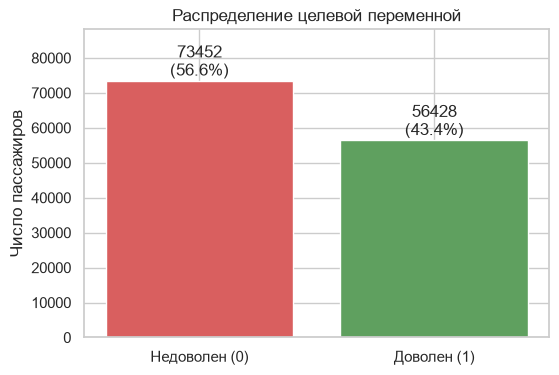

In [8]:
counts = df['satisfaction'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Недоволен (0)', 'Доволен (1)'], counts.values, color=['#d95f5f', '#5fa05f'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 1500, f'{v}\n({v / len(df):.1%})', ha='center')
ax.set_ylabel('Число пассажиров')
ax.set_title('Распределение целевой переменной')
ax.set_ylim(0, counts.max() * 1.2)
save_fig('01_target_distribution.png')
plt.show()

**Рисунок 1 — Распределение целевой переменной**

Недовольных 73 452 (56,6 %), довольных 56 428 (43,4 %), перекос небольшой, поэтому accuracy годится как основная метрика.

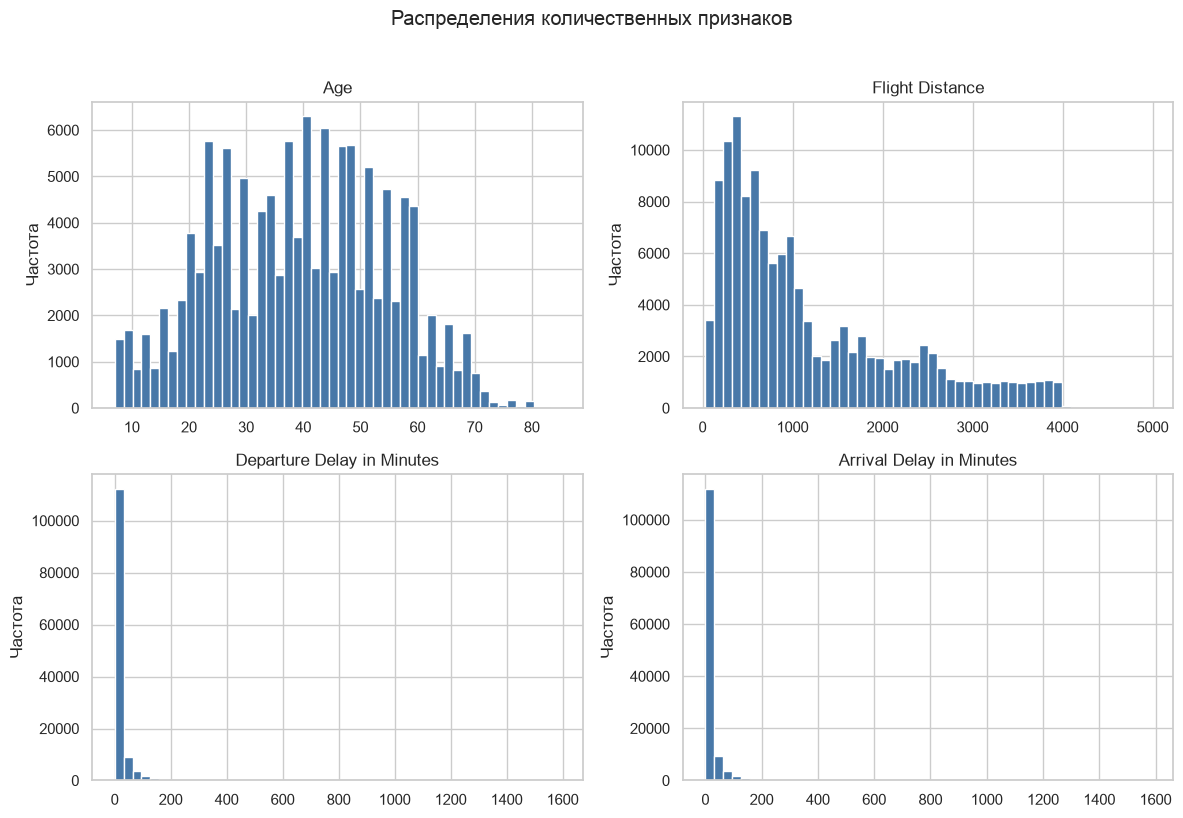

Рейсов без задержки вылета: 56.5%


In [9]:
numeric_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(df[col], bins=50, color='#4878a8', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Частота')
fig.suptitle('Распределения количественных признаков', y=1.02)
fig.tight_layout()
save_fig('02_numeric_distributions.png')
plt.show()

print(f"Рейсов без задержки вылета: {(df['Departure Delay in Minutes'] == 0).mean():.1%}")

**Рисунок 2 — Распределения количественных признаков**

Возраст распределён почти симметрично около 40 лет, а дальность и обе задержки сильно скошены вправо: у 56,5 % рейсов задержки вылета нет вообще.

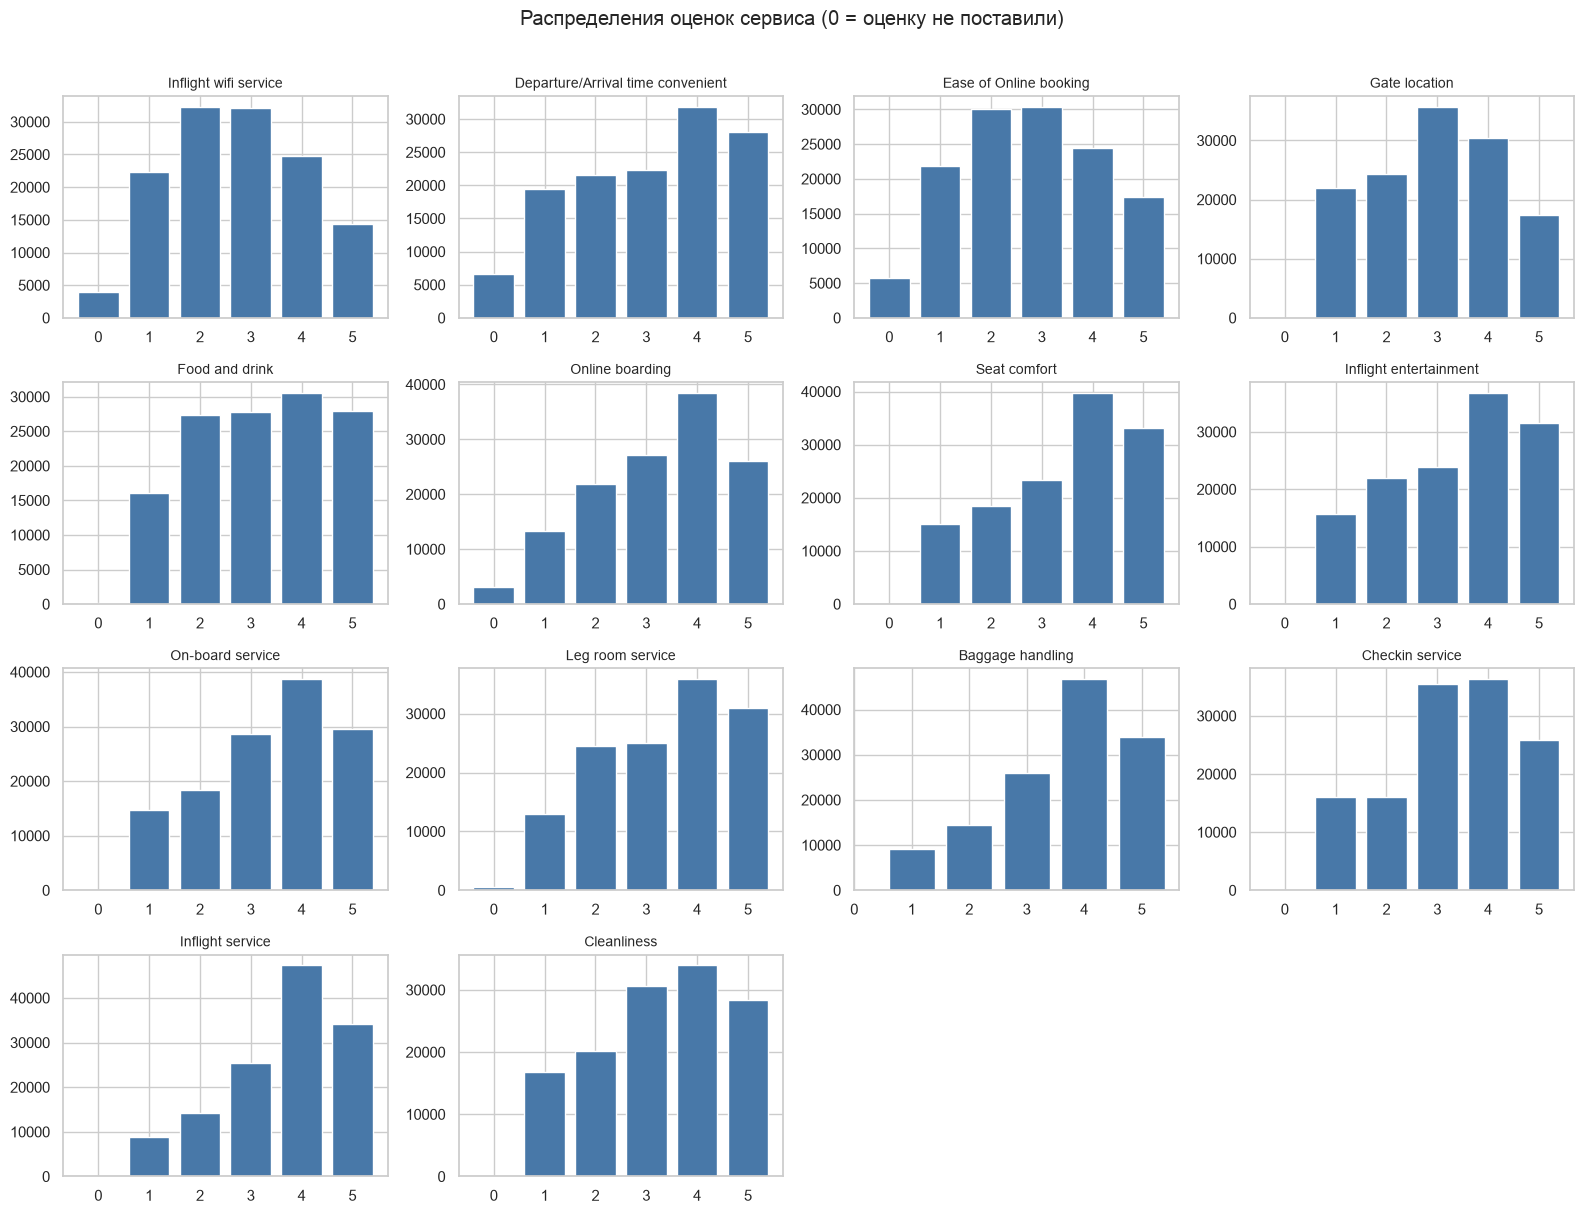

Средняя оценка, от худшей к лучшей:
Inflight wifi service                2.73
Ease of Online booking               2.76
Gate location                        2.98
Departure/Arrival time convenient    3.06
Food and drink                       3.20
Online boarding                      3.25
Cleanliness                          3.29
Checkin service                      3.31
Leg room service                     3.35
Inflight entertainment               3.36
On-board service                     3.38
Seat comfort                         3.44
Baggage handling                     3.63
Inflight service                     3.64
dtype: float64


In [10]:
service_cols = ['Inflight wifi service', 'Departure/Arrival time convenient',
                'Ease of Online booking', 'Gate location', 'Food and drink',
                'Online boarding', 'Seat comfort', 'Inflight entertainment',
                'On-board service', 'Leg room service', 'Baggage handling',
                'Checkin service', 'Inflight service', 'Cleanliness']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.ravel(), service_cols):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color='#4878a8')
    ax.set_title(col, fontsize=10)
    ax.set_xticks(range(6))
# две лишние ячейки сетки прячем
for ax in axes.ravel()[len(service_cols):]:
    ax.axis('off')
fig.suptitle('Распределения оценок сервиса (0 = оценку не поставили)', y=1.01)
fig.tight_layout()
save_fig('03_service_ratings.png')
plt.show()

print('Средняя оценка, от худшей к лучшей:')
print(df[service_cols].mean().sort_values().round(2))

**Рисунок 3 — Распределения оценок сервиса**

Чаще всего сервис оценивают на 4, а слабее всего Wi-Fi на борту (среднее 2,73) и онлайн-бронирование (2,76).

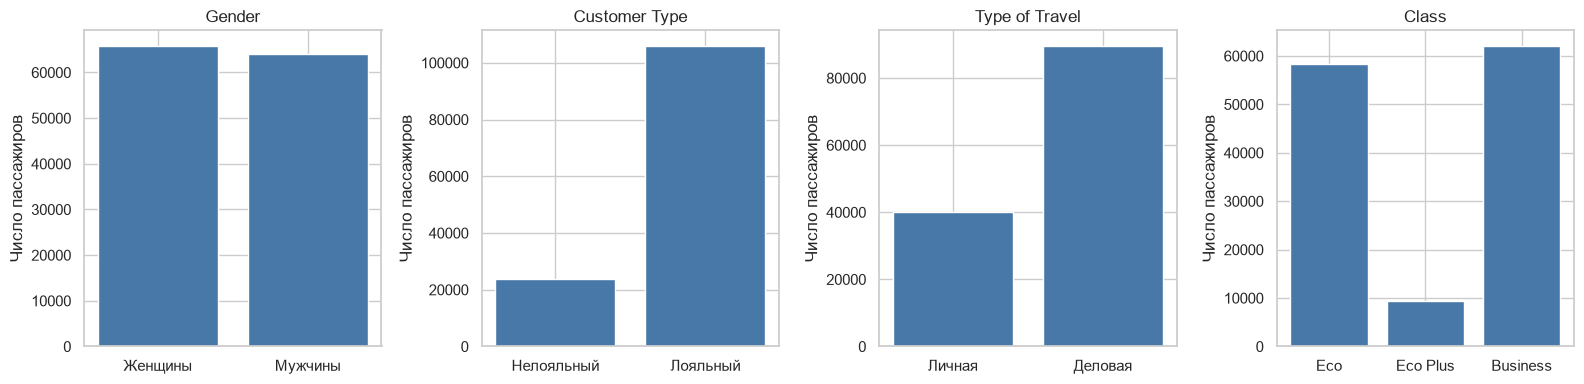

Gender {0: 0.507, 1: 0.493}
Customer Type {0: 0.183, 1: 0.817}
Type of Travel {0: 0.309, 1: 0.691}
Class {0: 0.449, 1: 0.072, 2: 0.479}


In [11]:
cat_info = [('Gender', ['Женщины', 'Мужчины']),
            ('Customer Type', ['Нелояльный', 'Лояльный']),
            ('Type of Travel', ['Личная', 'Деловая']),
            ('Class', ['Eco', 'Eco Plus', 'Business'])]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (col, labels) in zip(axes, cat_info):
    vc = df[col].value_counts().sort_index()
    ax.bar(labels, vc.values, color='#4878a8')
    ax.set_title(col)
    ax.set_ylabel('Число пассажиров')
fig.tight_layout()
save_fig('04_categorical_distributions.png')
plt.show()

for col, _ in cat_info:
    print(col, df[col].value_counts(normalize=True).sort_index().round(3).to_dict())

**Рисунок 4 — Распределения категориальных признаков**

Лояльных клиентов 81,7 %, деловых поездок 69,1 %, а классом Eco Plus летает всего 7,2 % пассажиров, так что выводы по этому классу опираются на меньшую выборку.

### 4.3 Выбросы

Выбросы ищу «ящиками с усами». Ус заканчивается на расстоянии 1,5 межквартильного размаха
от квартилей, всё что дальше считается выбросом.

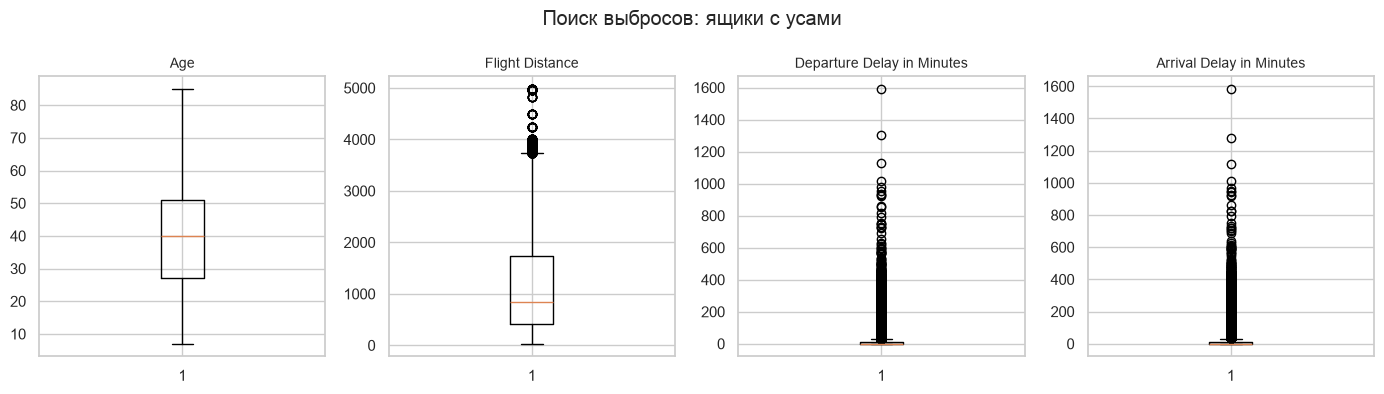

Age                          выбросов:      0 (0.0%), максимум 85
Flight Distance              выбросов:   2855 (2.2%), максимум 4983
Departure Delay in Minutes   выбросов:  18098 (13.9%), максимум 1592
Arrival Delay in Minutes     выбросов:  17492 (13.5%), максимум 1584


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col])
    ax.set_title(col, fontsize=10)
fig.suptitle('Поиск выбросов: ящики с усами')
fig.tight_layout()
save_fig('05_boxplots.png')
plt.show()

# сколько значений за верхним усом
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    n_out = (df[col] > q3 + 1.5 * (q3 - q1)).sum()
    print(f'{col:28} выбросов: {n_out:6} ({n_out / len(df):.1%}), максимум {df[col].max():.0f}')

**Рисунок 5 — Ящики с усами для количественных признаков**

За верхним усом 18 098 значений задержки вылета (13,9 %) и 2 855 значений дальности (2,2 %), а самая большая задержка 1592 минуты, почти 27 часов.

Удалять эти значения не буду. Задержка на сутки случается в реальности, это не ошибка ввода,
а пассажир с такой задержкой как раз интересен для модели. Деревьям выбросы не мешают,
а для kNN и логистической регрессии в пункте 8 стандартизирую признаки.

### 4.4 Проверка на нормальность

Критерий Шапиро–Уилка на случайной подвыборке из 5000 строк. На всех 130 тысячах тест
отверг бы нормальность из-за любого крошечного отклонения, и scipy сам предупреждает,
что p-value при n > 5000 неточен.

In [13]:
sample = df.sample(5000, random_state=RANDOM_STATE)
print(f"{'Признак':30} {'Среднее':>10} {'Дисперсия':>12} {'Медиана':>9} {'p-value':>10}")
for col in numeric_cols:
    stat, p = stats.shapiro(sample[col])
    print(f'{col:30} {df[col].mean():10.2f} {df[col].var():12.2f} {df[col].median():9.1f} {p:10.2e}')

Признак                           Среднее    Дисперсия   Медиана    p-value
Age                                 39.43       228.60      40.0   1.37e-18
Flight Distance                   1190.32    994911.44     844.0   3.81e-54
Departure Delay in Minutes          14.71      1449.41       0.0   9.64e-84
Arrival Delay in Minutes            15.05      1475.82       0.0   1.87e-83


У всех четырёх признаков p-value намного меньше 0,05, гипотезу о нормальности отвергаю.
Поэтому для описания центра распределения смотрю на медиану, а не только на среднее.

### 4.5 Корреляции

Тепловая карта корреляций Пирсона нужна, чтобы найти признаки, сильнее всего связанные
с целью, пары признаков, которые дублируют друг друга, и признаки, почти не связанные с целью.

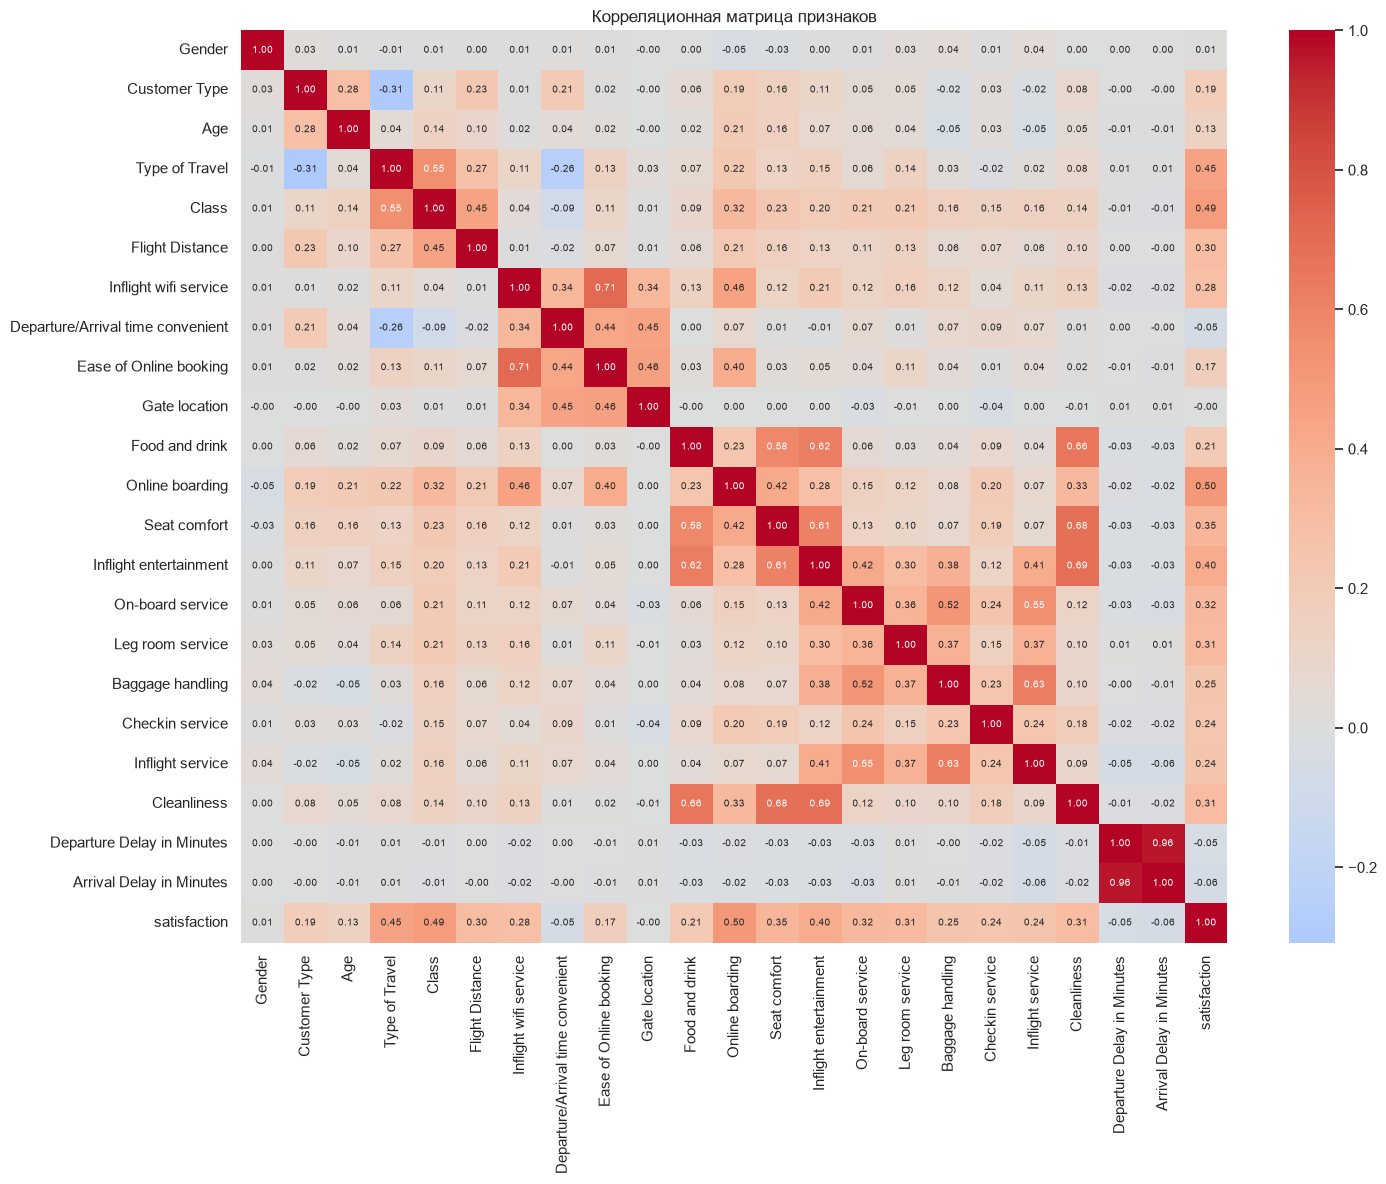

In [14]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Корреляционная матрица признаков')
fig.tight_layout()
save_fig('06_correlation_heatmap.png')
plt.show()

**Рисунок 6 — Корреляционная матрица признаков**

Почти дублируют друг друга только задержки вылета и прилёта (r = 0,96), остальные пары признаков связаны не сильнее r = 0,71.

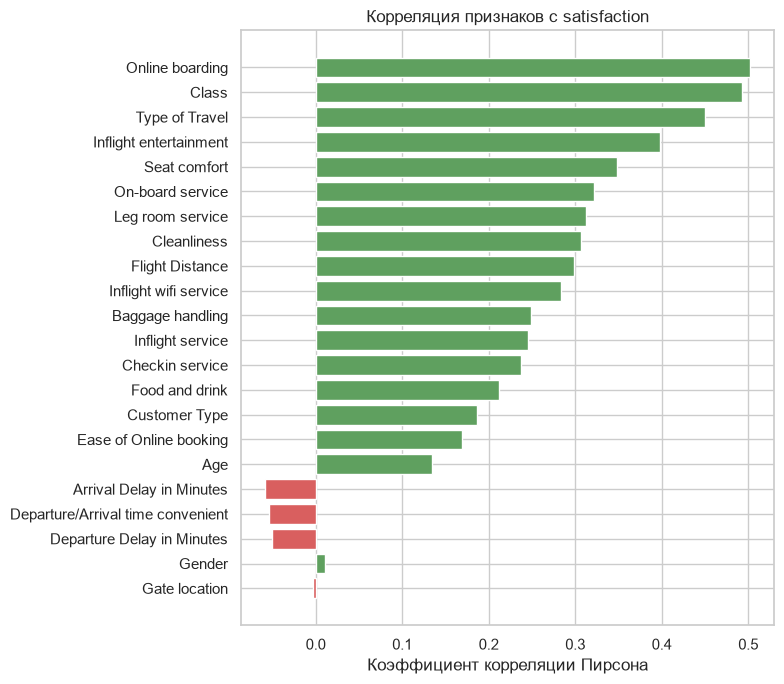

Online boarding                      0.502
Class                                0.493
Type of Travel                       0.450
Inflight entertainment               0.398
Seat comfort                         0.349
On-board service                     0.322
Leg room service                     0.312
Cleanliness                          0.307
Flight Distance                      0.298
Inflight wifi service                0.283
Baggage handling                     0.249
Inflight service                     0.245
Checkin service                      0.237
Food and drink                       0.211
Customer Type                        0.186
Ease of Online booking               0.169
Age                                  0.134
Arrival Delay in Minutes            -0.058
Departure/Arrival time convenient   -0.054
Departure Delay in Minutes          -0.051
Gender                               0.011
Gate location                       -0.003
Name: satisfaction, dtype: float64


In [15]:
# корреляция с целью, по убыванию модуля
target_corr = corr['satisfaction'].drop('satisfaction').sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#5fa05f' if v > 0 else '#d95f5f' for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1])
ax.set_title('Корреляция признаков с satisfaction')
ax.set_xlabel('Коэффициент корреляции Пирсона')
fig.tight_layout()
save_fig('07_target_correlations.png')
plt.show()

print(target_corr.round(3))

**Рисунок 7 — Корреляция признаков с целевой переменной**

Сильнее всего с удовлетворённостью связаны Online boarding (r = 0,50), Class (0,49) и Type of Travel (0,45), а у Gender (0,011) и Gate location (−0,003) линейной связи с целью почти нет.

In [16]:
# пары признаков с |r| > 0.5 (без цели)
feat_corr = corr.drop(index='satisfaction', columns='satisfaction')
pairs = (feat_corr.where(np.triu(np.ones(feat_corr.shape, dtype=bool), k=1))
         .stack().sort_values(key=abs, ascending=False))
print(pairs[abs(pairs) > 0.5].round(2))

Departure Delay in Minutes  Arrival Delay in Minutes    0.96
Inflight wifi service       Ease of Online booking      0.71
Inflight entertainment      Cleanliness                 0.69
Seat comfort                Cleanliness                 0.68
Food and drink              Cleanliness                 0.66
Baggage handling            Inflight service            0.63
Food and drink              Inflight entertainment      0.62
Seat comfort                Inflight entertainment      0.61
Food and drink              Seat comfort                0.58
On-board service            Inflight service            0.55
Type of Travel              Class                       0.55
On-board service            Baggage handling            0.52
dtype: float64


**Что получилось в корреляционном анализе:**
- сильнее всего с удовлетворённостью связаны Online boarding, Class, Type of Travel,
  Inflight entertainment и Seat comfort;
- почти не связаны с целью Gender, Gate location и Departure/Arrival time convenient.
  Это кандидаты на удаление в пункте 8;
- задержки вылета и прилёта коррелируют на 0,96, одну из них можно выбросить без потери информации.

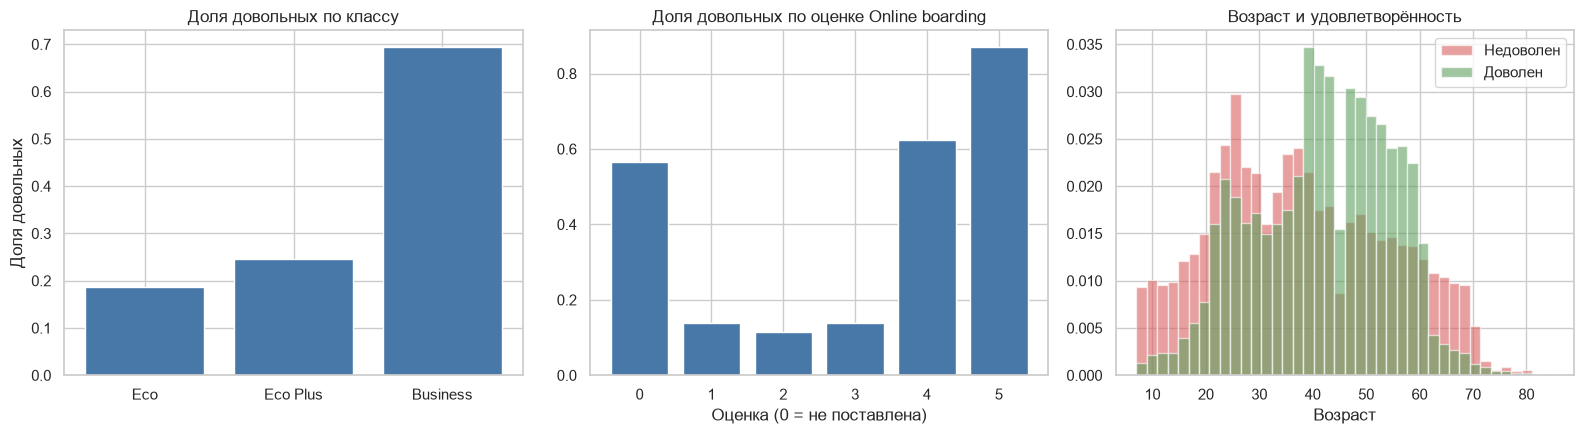

По классу: {0: 0.188, 1: 0.246, 2: 0.694}
По Online boarding: {0: 0.565, 1: 0.138, 2: 0.115, 3: 0.138, 4: 0.623, 5: 0.871}
По возрасту: {Interval(0, 20, closed='right'): 0.199, Interval(20, 40, closed='right'): 0.399, Interval(40, 60, closed='right'): 0.577, Interval(60, 100, closed='right'): 0.208}


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# доля довольных по классу
class_sat = df.groupby('Class')['satisfaction'].mean()
axes[0].bar(['Eco', 'Eco Plus', 'Business'], class_sat.values, color='#4878a8')
axes[0].set_title('Доля довольных по классу')
axes[0].set_ylabel('Доля довольных')

# доля довольных по оценке онлайн-посадки
ob_sat = df.groupby('Online boarding')['satisfaction'].mean()
axes[1].bar(ob_sat.index, ob_sat.values, color='#4878a8')
axes[1].set_title('Доля довольных по оценке Online boarding')
axes[1].set_xlabel('Оценка (0 = не поставлена)')

# возраст у довольных и недовольных
axes[2].hist(df[df['satisfaction'] == 0]['Age'], bins=40, alpha=0.6,
             label='Недоволен', color='#d95f5f', density=True)
axes[2].hist(df[df['satisfaction'] == 1]['Age'], bins=40, alpha=0.6,
             label='Доволен', color='#5fa05f', density=True)
axes[2].set_title('Возраст и удовлетворённость')
axes[2].set_xlabel('Возраст')
axes[2].legend()

fig.tight_layout()
save_fig('08_joint_distributions.png')
plt.show()

print('По классу:', class_sat.round(3).to_dict())
print('По Online boarding:', ob_sat.round(3).to_dict())
age_groups = pd.cut(df['Age'], [0, 20, 40, 60, 100])
print('По возрасту:', df.groupby(age_groups, observed=True)['satisfaction'].mean().round(3).to_dict())

**Рисунок 8 — Доля довольных пассажиров в разрезе класса, оценки онлайн-посадки и возраста**

Доля довольных растёт с классом (18,8 % в Eco и 69,4 % в Business), резко прыгает на оценках онлайн-посадки 4 и 5 (62,3 % и 87,1 %), а по возрасту выше всего у пассажиров 40–60 лет (57,7 %).

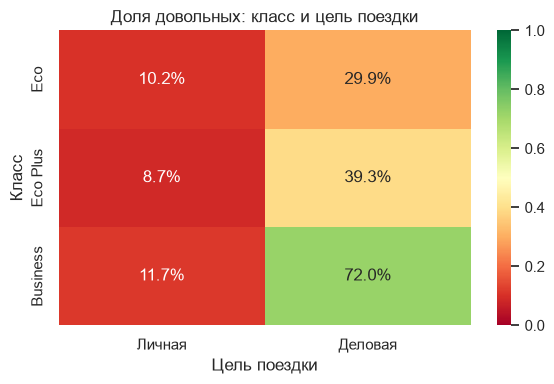

Число пассажиров в каждой ячейке:
Type of Travel      0      1
Class                       
0               33005  25304
1                4509   4902
2                2673  59487


In [18]:
# доля довольных в каждой комбинации класса и цели поездки
pivot = df.pivot_table(index='Class', columns='Type of Travel', values='satisfaction', aggfunc='mean')
pivot.index = ['Eco', 'Eco Plus', 'Business']
pivot.columns = ['Личная', 'Деловая']
sizes = df.pivot_table(index='Class', columns='Type of Travel', values='satisfaction', aggfunc='size')

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=1, ax=ax)
ax.set_title('Доля довольных: класс и цель поездки')
ax.set_xlabel('Цель поездки')
ax.set_ylabel('Класс')
fig.tight_layout()
save_fig('09_class_travel_heatmap.png')
plt.show()

print('Число пассажиров в каждой ячейке:')
print(sizes)

**Рисунок 9 — Доля довольных пассажиров по классу и цели поездки**

В личных поездках довольны всего 9–12 % пассажиров в любом классе, а в деловых доля растёт с 29,9 % в Eco до 72,0 % в Business, то есть дорогой класс поднимает удовлетворённость только у тех, кто летит по работе.

## 5. Обучение без учителя

Хочу проверить, делятся ли пассажиры на естественные группы без подсказки меток.
- **K-Means** разбивает объекты на k кластеров, минимизируя сумму квадратов расстояний до центров (инерцию).
  Число кластеров выбираю методом локтя.
- **PCA** сжимает 22 признака до двух главных компонент, чтобы нарисовать данные на плоскости.

Оба метода считают расстояния, поэтому признаки сначала стандартизирую. Иначе Flight Distance
(тысячи километров) задавил бы оценки сервиса (от 0 до 5).

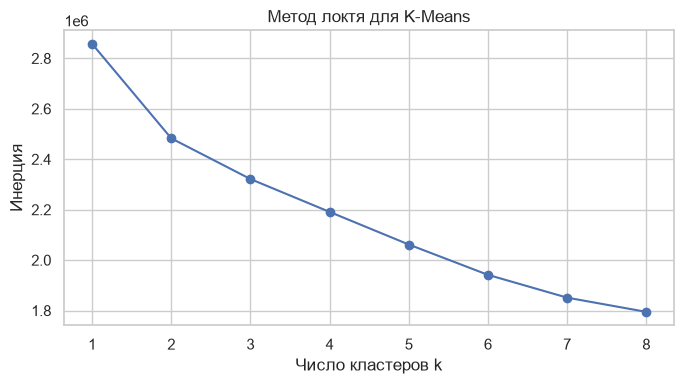

k=1: инерция 2,857,360
k=2: инерция 2,482,744
k=3: инерция 2,321,304
k=4: инерция 2,190,988
k=5: инерция 2,061,697
k=6: инерция 1,941,442
k=7: инерция 1,851,031
k=8: инерция 1,794,612


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

X_all = df.drop(columns=['satisfaction'])
y_all = df['satisfaction']
X_scaled = StandardScaler().fit_transform(X_all)

# метод локтя: инерция для k от 1 до 8
k_values = range(1, 9)
inertia = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_values), inertia, 'o-')
ax.set_xlabel('Число кластеров k')
ax.set_ylabel('Инерция')
ax.set_title('Метод локтя для K-Means')
fig.tight_layout()
save_fig('10_kmeans_elbow.png')
plt.show()

for k, v in zip(k_values, inertia):
    print(f'k={k}: инерция {v:,.0f}')

**Рисунок 10 — Метод локтя для K-Means**

Явного локтя нет, инерция падает плавно с 2,86 млн при k = 1 до 1,79 млн при k = 8, поэтому чётких естественных групп в данных нет и k = 2 я беру по числу классов.

Доля объяснённой дисперсии: [0.186 0.108], суммарно 29.4%


Скорректированный индекс Рэнда (кластеры против настоящих классов): 0.282


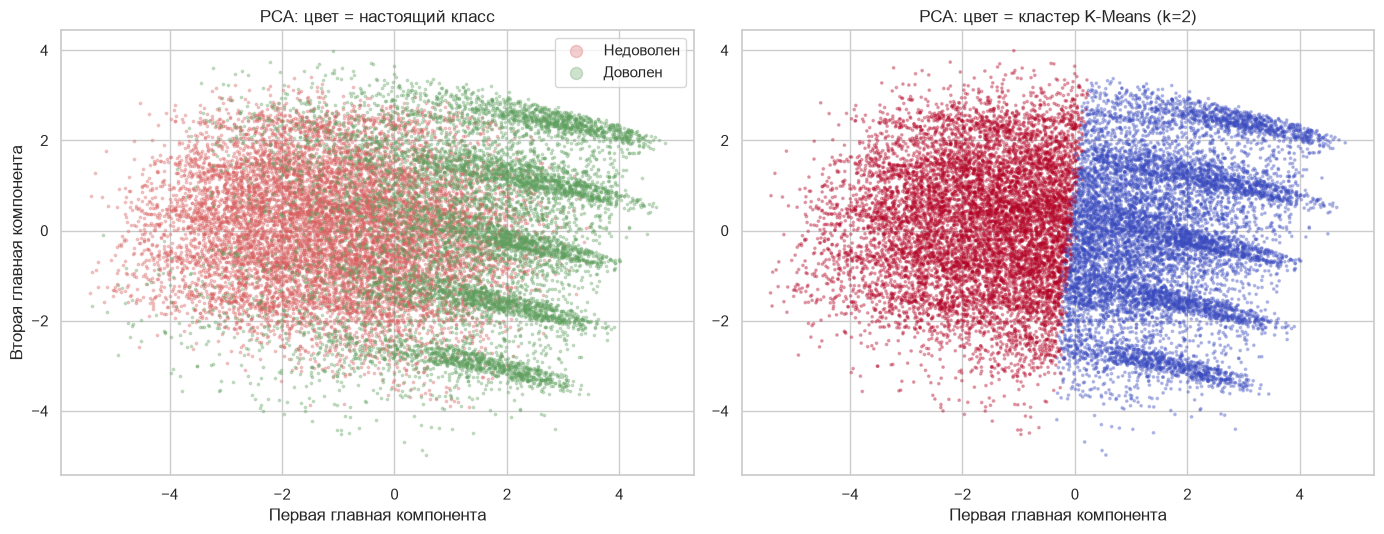

In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f'Доля объяснённой дисперсии: {pca.explained_variance_ratio_.round(3)}, '
      f'суммарно {pca.explained_variance_ratio_.sum():.1%}')

kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(X_scaled)
ari = adjusted_rand_score(y_all, clusters)
print(f'Скорректированный индекс Рэнда (кластеры против настоящих классов): {ari:.3f}')

# рисуем 20 тысяч случайных точек, иначе всё сливается в пятно
idx = np.random.RandomState(RANDOM_STATE).choice(len(df), 20000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for label, color, name in [(0, '#d95f5f', 'Недоволен'), (1, '#5fa05f', 'Доволен')]:
    mask = y_all.iloc[idx].values == label
    axes[0].scatter(X_pca[idx][mask, 0], X_pca[idx][mask, 1], s=3, alpha=0.3, color=color, label=name)
axes[0].set_title('PCA: цвет = настоящий класс')
axes[0].set_xlabel('Первая главная компонента')
axes[0].set_ylabel('Вторая главная компонента')
axes[0].legend(markerscale=5)

axes[1].scatter(X_pca[idx][:, 0], X_pca[idx][:, 1], s=3, alpha=0.3, c=clusters[idx], cmap='coolwarm')
axes[1].set_title('PCA: цвет = кластер K-Means (k=2)')
axes[1].set_xlabel('Первая главная компонента')

fig.tight_layout()
save_fig('11_pca_kmeans.png')
plt.show()

**Рисунок 11 — Проекция данных на две главные компоненты: настоящие классы и кластеры K-Means**

Две главные компоненты объясняют только 29,4 % дисперсии, классы на плоскости перемешаны, а кластеры K-Means совпадают с классами слабо (ARI = 0,28 при максимуме 1).

**Вывод по обучению без учителя.** Кластеры K-Means не повторяют деление на довольных и недовольных.
Без меток задачу не решить, нужны модели обучения с учителем.

## 6. Разбиение выборки и обучение моделей

### 6.1 Разбиение на обучающую и тестовую

- **Случайное разбиение** (`train_test_split`). Анкеты независимы друг от друга и не упорядочены
  по времени, поэтому разбивать по дате или по порядку строк смысла нет.
- **75 % на обучение, 25 % на тест.** Обучающих строк около 97 тысяч, моделям этого хватает.
  В тесте 32 тысячи строк, стандартная ошибка accuracy при таком объёме около 0,1 процентного пункта.
- **Стратификация по цели** (`stratify=y`): доля довольных в обеих частях одинаковая.

Кросс-валидацию на всех данных не беру: тест должен остаться нетронутым до конца,
а кросс-валидацию использую внутри обучающей выборки при подборе гиперпараметров.

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print(f'Обучающая выборка: {X_train.shape[0]} строк')
print(f'Тестовая выборка:  {X_test.shape[0]} строк')
print(f'Доля довольных: в обучении {y_train.mean():.3f}, в тесте {y_test.mean():.3f}')

Обучающая выборка: 97410 строк
Тестовая выборка:  32470 строк
Доля довольных: в обучении 0.434, в тесте 0.434


### 6.2 Пять моделей

1. **Логистическая регрессия.** Линейная модель: взвешенная сумма признаков проходит через сигмоиду
   и превращается в вероятность. Базовый уровень: если сложные модели её не обгонят, они не нужны.
2. **k ближайших соседей (kNN).** Класс нового пассажира решают 5 самых похожих пассажиров из обучения.
3. **Дерево решений.** Набор правил вида «если Online boarding ≤ 3, то…». Масштаб признаков ему не важен.
4. **Случайный лес.** Сотня деревьев, каждое на своей бутстреп-подвыборке и случайном наборе признаков.
   Ответ выбирается голосованием, поэтому лес переобучается меньше одного дерева.
5. **Градиентный бустинг** (`HistGradientBoostingClassifier`). Деревья строятся по очереди,
   каждое следующее исправляет ошибки предыдущих. Приставка Hist означает, что значения признаков
   раскладываются на 255 корзин, так обучение на 100 тысячах строк занимает секунды.

Сначала все пять модели обучаю с параметрами по умолчанию на исходных, немасштабированных данных.
Это точка «до», с ней сравниваю улучшения в пункте 8.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

models = {
    'Логистическая регрессия': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'kNN': KNeighborsClassifier(n_jobs=-1),
    'Дерево решений': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Случайный лес': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'Градиентный бустинг': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    print(f'{name:25} обучена за {time.time() - t0:.1f} с')

/Users/f.arutyunyan/Documents/personal/mospolytech/mmo/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Логистическая регрессия   обучена за 1.9 с
kNN                       обучена за 0.0 с


Дерево решений            обучена за 0.3 с


Случайный лес             обучена за 0.8 с


Градиентный бустинг       обучена за 2.6 с


Предупреждение `ConvergenceWarning` у логистической регрессии ожидаемое: без масштабирования
признаки с большими значениями мешают оптимизатору сойтись за 1000 итераций. Исправляю в пункте 8.

## 7. Оценка моделей

Все метрики считаю на тестовой выборке, которую модели не видели:
- **Accuracy**: доля верных ответов;
- **Precision**: из тех, кого модель назвала довольным, какая доля правда довольна;
- **Recall**: какую долю реально довольных модель нашла;
- **F1**: гармоническое среднее precision и recall;
- **ROC-AUC**: вероятность, что случайный довольный получит от модели больший балл, чем случайный недовольный.
  Не зависит от порога 0,5.

In [23]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)


def evaluate(model, X_eval, y_eval):
    # словарь метрик модели на переданной выборке
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    return {
        'Accuracy': accuracy_score(y_eval, y_pred),
        'Precision': precision_score(y_eval, y_pred),
        'Recall': recall_score(y_eval, y_pred),
        'F1': f1_score(y_eval, y_pred),
        'ROC-AUC': roc_auc_score(y_eval, y_proba),
    }


results = pd.DataFrame({name: evaluate(m, X_test, y_test) for name, m in models.items()}).T
results.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Логистическая регрессия,0.8686,0.8560,0.8387,0.8472,0.9238
kNN,0.7528,0.7346,0.6747,0.7034,0.8102
Дерево решений,0.9464,0.9377,0.9391,0.9384,0.9456
Случайный лес,0.9622,0.9719,0.9403,0.9558,0.9940
Градиентный бустинг,0.9633,0.9742,0.9405,0.9570,0.9951


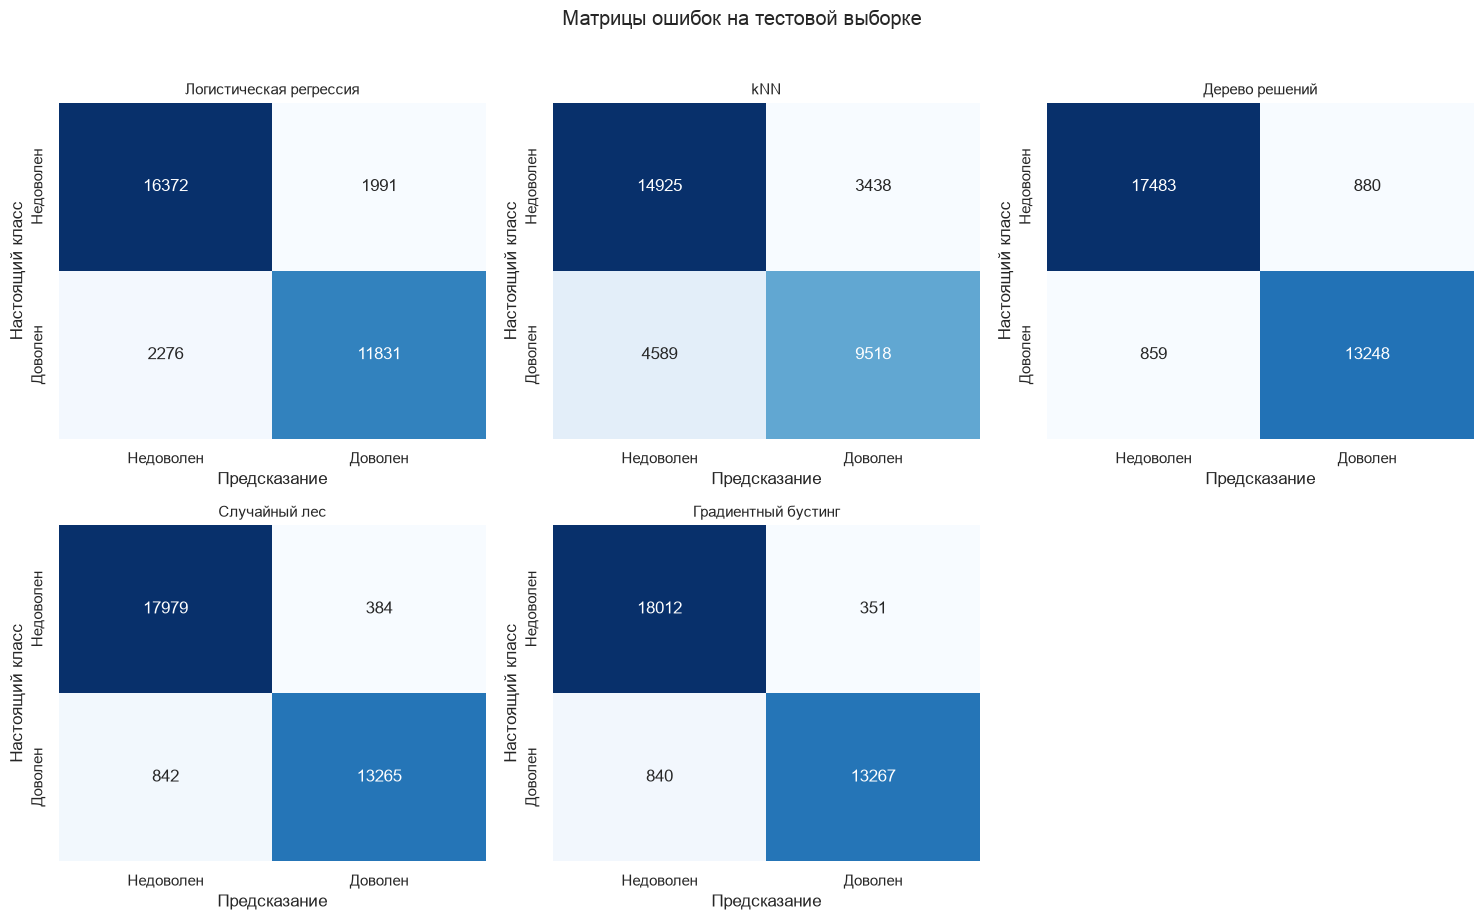

Логистическая регрессия   ложно довольные:  1991, пропущенные довольные:  2276


kNN                       ложно довольные:  3438, пропущенные довольные:  4589
Дерево решений            ложно довольные:   880, пропущенные довольные:   859
Случайный лес             ложно довольные:   384, пропущенные довольные:   842
Градиентный бустинг       ложно довольные:   351, пропущенные довольные:   840


In [24]:
# сетка 2x3, чтобы матрицы читались в отчёте; шестая ячейка пустая
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes[1, 2].axis('off')
for ax, (name, model) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Недоволен', 'Доволен'], yticklabels=['Недоволен', 'Доволен'])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Настоящий класс')
fig.suptitle('Матрицы ошибок на тестовой выборке', y=1.02)
fig.tight_layout()
save_fig('12_confusion_matrices.png')
plt.show()

for name, model in models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, model.predict(X_test)).ravel()
    print(f'{name:25} ложно довольные: {fp:5}, пропущенные довольные: {fn:5}')

**Рисунок 12 — Матрицы ошибок базовых моделей**

Ансамбли чаще пропускают довольных, чем ошибочно записывают пассажира в довольные (у бустинга 840 пропусков против 351 ложного срабатывания), а больше всего ошибок у kNN без масштабирования: 4 589 и 3 438.

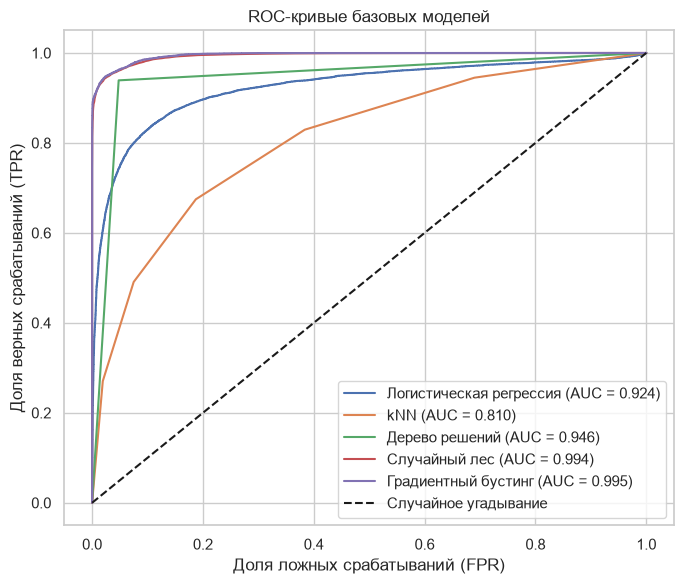

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')
ax.set_xlabel('Доля ложных срабатываний (FPR)')
ax.set_ylabel('Доля верных срабатываний (TPR)')
ax.set_title('ROC-кривые базовых моделей')
ax.legend()
fig.tight_layout()
save_fig('13_roc_curves.png')
plt.show()

**Рисунок 13 — ROC-кривые базовых моделей**

Кривые бустинга (AUC = 0,995) и случайного леса (0,994) почти прижаты к левому верхнему углу, у дерева AUC всего 0,946 из-за грубых вероятностей, а у kNN без масштабирования 0,810.

**Что получилось на базовых моделях:**

- Лучший результат у градиентного бустинга: accuracy 0,9633, ROC-AUC 0,9951. Случайный лес отстаёт на 0,1 процентного пункта.
- Одно дерево даёт accuracy 0,9464, но ROC-AUC только 0,9456. Вероятность у дерева равна доле класса в листе,
  и почти во всех листьях это 0 или 1, поэтому ранжирует пассажиров оно хуже ансамблей.
- Логистическая регрессия (0,8686) заметно слабее деревьев, потому что зависимость нелинейная.
  По рисунку 8 при оценке онлайн-посадки 3 довольны 13,8 % пассажиров, а при оценке 4 уже 62,3 %.
  Такой скачок одной взвешенной суммой не описать.
- kNN хуже всех (0,7528). Без масштабирования расстояние между пассажирами почти целиком задаёт
  Flight Distance (до 4983 км), а оценки сервиса от 0 до 5 на него почти не влияют.

## 8. Улучшение моделей

Три приёма, для каждого сравниваю метрики до и после:
1. **Стандартизация** для логистической регрессии и kNN. Из каждого признака вычитаю среднее и делю
   на стандартное отклонение. Среднее и отклонение считаю только по обучающей выборке, иначе
   информация из теста просочится в обучение. Деревьям, лесу и бустингу стандартизация не нужна:
   они сравнивают признак с порогом, и от сдвига шкалы порог просто сдвигается вместе с ней.
2. **Отбор признаков** для лучшей базовой модели. Убираю Gender, Gate location,
   Departure/Arrival time convenient (почти не связаны с целью) и Departure Delay
   (дублирует Arrival Delay, r = 0,96).
3. **Подбор гиперпараметров** лучшей модели по сетке с 3-кратной кросс-валидацией на обучающей выборке.

In [26]:
# приём 1: стандартизация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # среднее и отклонение только по обучению
X_test_scaled = scaler.transform(X_test)

scaled_models = {
    'Логистическая регрессия + масштаб': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'kNN + масштаб': KNeighborsClassifier(n_jobs=-1),
}
for name, model in scaled_models.items():
    model.fit(X_train_scaled, y_train)

scaled_results = pd.DataFrame({name: evaluate(m, X_test_scaled, y_test)
                               for name, m in scaled_models.items()}).T
pd.concat([results.loc[['Логистическая регрессия', 'kNN']], scaled_results]).round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Логистическая регрессия,0.8686,0.8560,0.8387,0.8472,0.9238
kNN,0.7528,0.7346,0.6747,0.7034,0.8102
Логистическая регрессия + масштаб,0.8747,0.8707,0.8355,0.8528,0.9275
kNN + масштаб,0.9283,0.9460,0.8855,0.9148,0.9705


Стандартизация подняла kNN с 0,7528 до 0,9283, это +17,6 процентного пункта: теперь все признаки
вносят в расстояние сравнимый вклад. Логистическая регрессия выросла всего на 0,6 п. п. (0,8686 → 0,8747).
Линейная модель и так подбирает вес под масштаб признака, стандартизация в основном помогла
оптимизатору сойтись, и предупреждение о сходимости пропало.

In [27]:
# приём 2: отбор признаков для градиентного бустинга
drop_cols = ['Gender', 'Gate location', 'Departure/Arrival time convenient', 'Departure Delay in Minutes']
X_train_sel = X_train.drop(columns=drop_cols)
X_test_sel = X_test.drop(columns=drop_cols)

hgb_sel = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
hgb_sel.fit(X_train_sel, y_train)

selection_results = pd.DataFrame({
    f'Бустинг: {X_train.shape[1]} признака': evaluate(models['Градиентный бустинг'], X_test, y_test),
    f'Бустинг: {X_train_sel.shape[1]} признаков': evaluate(hgb_sel, X_test_sel, y_test),
}).T
selection_results.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Бустинг: 22 признака,0.9633,0.9742,0.9405,0.9570,0.9951
Бустинг: 18 признаков,0.9621,0.9748,0.9371,0.9555,0.9946


Отбор признаков не помог: accuracy упала с 0,9633 до 0,9621 (−0,12 п. п.), recall с 0,9405 до 0,9371.
Причину видно на рисунке 16 ниже. У Gate location корреляция с целью почти нулевая, но бустинг использует
этот признак в сочетании с другими, и его перестановочная важность (0,0098) даже выше, чем у Class.
Корреляция Пирсона ловит только линейную связь, поэтому для бустинга оставляю все 22 признака.

**Подбор гиперпараметров бустинга.** Перебираю три параметра:
- `learning_rate`: насколько сильно каждое новое дерево поправляет предыдущие;
- `max_leaf_nodes`: максимум листьев в одном дереве, то есть его сложность;
- `l2_regularization`: штраф за слишком большие значения в листьях, защита от переобучения.

Число деревьев не перебираю: ставлю верхнюю границу 500, а ранняя остановка сама прекращает
обучение, когда качество на отложенных 10 % обучающей выборки перестаёт расти.

In [28]:
# приём 3: подбор гиперпараметров по сетке
from sklearn.model_selection import GridSearchCV

param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_leaf_nodes': [31, 63],
    'l2_regularization': [0.0, 1.0],
}
grid = GridSearchCV(
    HistGradientBoostingClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_STATE),
    param_grid, cv=3, scoring='accuracy', n_jobs=4)

t0 = time.time()
grid.fit(X_train, y_train)
print(f'Перебор {len(grid.cv_results_["params"])} комбинаций занял {time.time() - t0:.0f} с')
print('Лучшие параметры:', grid.best_params_)
print(f'Accuracy на кросс-валидации: {grid.best_score_:.4f}')

best_model = grid.best_estimator_
tuning_results = pd.DataFrame({
    'Бустинг (по умолчанию)': evaluate(models['Градиентный бустинг'], X_test, y_test),
    'Бустинг (после подбора)': evaluate(best_model, X_test, y_test),
}).T
tuning_results.round(4)

Перебор 12 комбинаций занял 41 с
Лучшие параметры: {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_leaf_nodes': 63}
Accuracy на кросс-валидации: 0.9646


,Accuracy,Precision,Recall,F1,ROC-AUC
Бустинг (по умолчанию),0.9633,0.9742,0.9405,0.9570,0.9951
Бустинг (после подбора),0.9651,0.9760,0.9429,0.9591,0.9957


Лучшая комбинация: `learning_rate = 0.05`, `max_leaf_nodes = 63`, `l2_regularization = 1.0`.
На кросс-валидации accuracy 0,9646, на тесте 0,9651 против 0,9633 у модели по умолчанию, прирост 0,18 п. п.
Меньший шаг и регуляризация сделали модель аккуратнее, но прирост маленький: параметры по умолчанию
уже были близки к хорошим. Оценки на кросс-валидации и на тесте почти совпадают, значит тест в подборе
не участвовал и под него ничего не подгонялось.

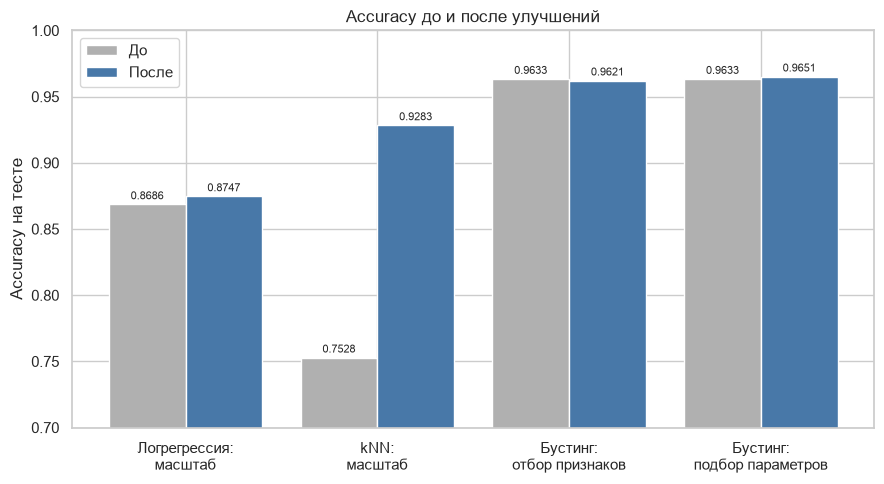

,До,После,"Прирост, п. п."
Логрегрессия: масштаб,0.8686,0.8747,0.6067
kNN: масштаб,0.7528,0.9283,17.5516
Бустинг: отбор признаков,0.9633,0.9621,-0.1201
Бустинг: подбор параметров,0.9633,0.9651,0.1786


In [29]:
# график до/после по accuracy для всех трёх приёмов
before_after = pd.DataFrame({
    'До': [results.loc['Логистическая регрессия', 'Accuracy'],
           results.loc['kNN', 'Accuracy'],
           selection_results.iloc[0]['Accuracy'],
           tuning_results.iloc[0]['Accuracy']],
    'После': [scaled_results.loc['Логистическая регрессия + масштаб', 'Accuracy'],
              scaled_results.loc['kNN + масштаб', 'Accuracy'],
              selection_results.iloc[1]['Accuracy'],
              tuning_results.iloc[1]['Accuracy']],
}, index=['Логрегрессия: масштаб', 'kNN: масштаб', 'Бустинг: отбор признаков', 'Бустинг: подбор параметров'])

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(before_after))
bars_before = ax.bar(x - 0.2, before_after['До'], 0.4, label='До', color='#b0b0b0')
bars_after = ax.bar(x + 0.2, before_after['После'], 0.4, label='После', color='#4878a8')
ax.bar_label(bars_before, fmt='%.4f', fontsize=8, padding=2)
ax.bar_label(bars_after, fmt='%.4f', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels([s.replace(': ', ':\n') for s in before_after.index])
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Accuracy на тесте')
ax.set_title('Accuracy до и после улучшений')
ax.legend()
fig.tight_layout()
save_fig('14_before_after.png')
plt.show()

before_after['Прирост, п. п.'] = (before_after['После'] - before_after['До']) * 100
before_after.round(4)

**Рисунок 14 — Accuracy до и после улучшений**

Сильнее всего помогла стандартизация для kNN (+17,6 п. п.), подбор гиперпараметров бустинга добавил 0,18 п. п., а отбор признаков по корреляции ухудшил accuracy на 0,12 п. п.

## 9. Итоговые результаты

### 9.1 Сравнение всех моделей

In [30]:
all_results = pd.concat([
    results,
    scaled_results,
    pd.DataFrame({'Градиентный бустинг (подбор)': evaluate(best_model, X_test, y_test)}).T,
]).sort_values('Accuracy', ascending=False)
all_results.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Градиентный бустинг (подбор),0.9651,0.9760,0.9429,0.9591,0.9957
Градиентный бустинг,0.9633,0.9742,0.9405,0.9570,0.9951
Случайный лес,0.9622,0.9719,0.9403,0.9558,0.9940
Дерево решений,0.9464,0.9377,0.9391,0.9384,0.9456
kNN + масштаб,0.9283,0.9460,0.8855,0.9148,0.9705
Логистическая регрессия + масштаб,0.8747,0.8707,0.8355,0.8528,0.9275
Логистическая регрессия,0.8686,0.8560,0.8387,0.8472,0.9238
kNN,0.7528,0.7346,0.6747,0.7034,0.8102


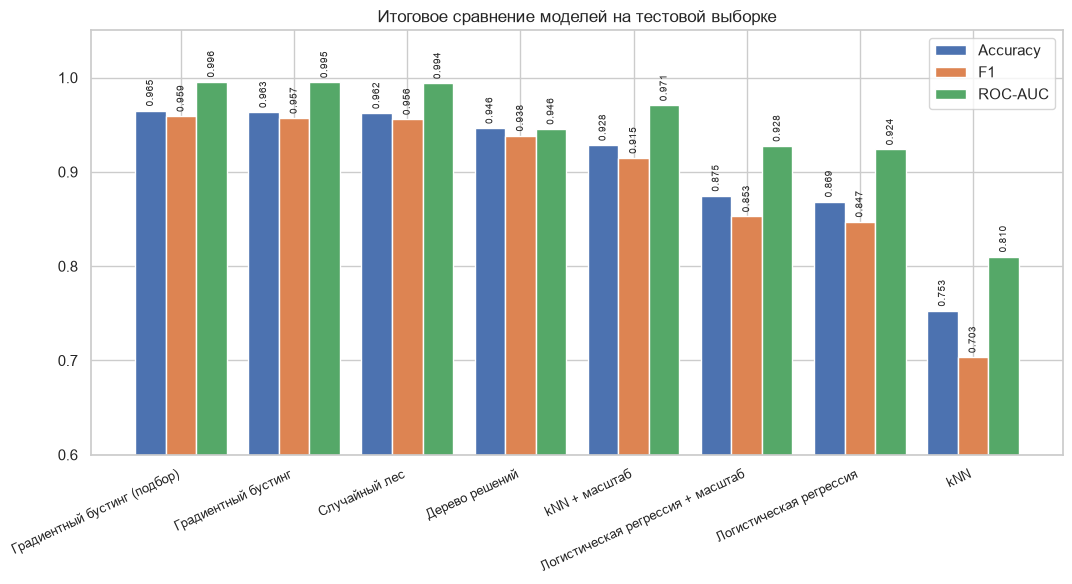

In [31]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = all_results[['Accuracy', 'F1', 'ROC-AUC']]
x = np.arange(len(plot_df))
width = 0.27
for i, metric in enumerate(plot_df.columns):
    bars = ax.bar(x + (i - 1) * width, plot_df[metric], width, label=metric)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, rotation=90, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0.6, 1.05)
ax.set_title('Итоговое сравнение моделей на тестовой выборке')
ax.legend(loc='upper right')
fig.tight_layout()
save_fig('15_final_comparison.png')
plt.show()

**Рисунок 15 — Итоговое сравнение моделей на тестовой выборке**

Первые три места у ансамблей деревьев (бустинг после подбора 0,9651, бустинг по умолчанию 0,9633, лес 0,9622), а последнее у kNN без масштабирования с accuracy 0,7528.

### 9.2 Какие признаки важны для лучшей модели

У бустинга в scikit-learn нет встроенной важности признаков, поэтому считаю перестановочную важность:
по очереди перемешиваю один столбец в тестовой выборке и смотрю, насколько падает accuracy.
Чем сильнее падение, тем больше модель опирается на этот признак.

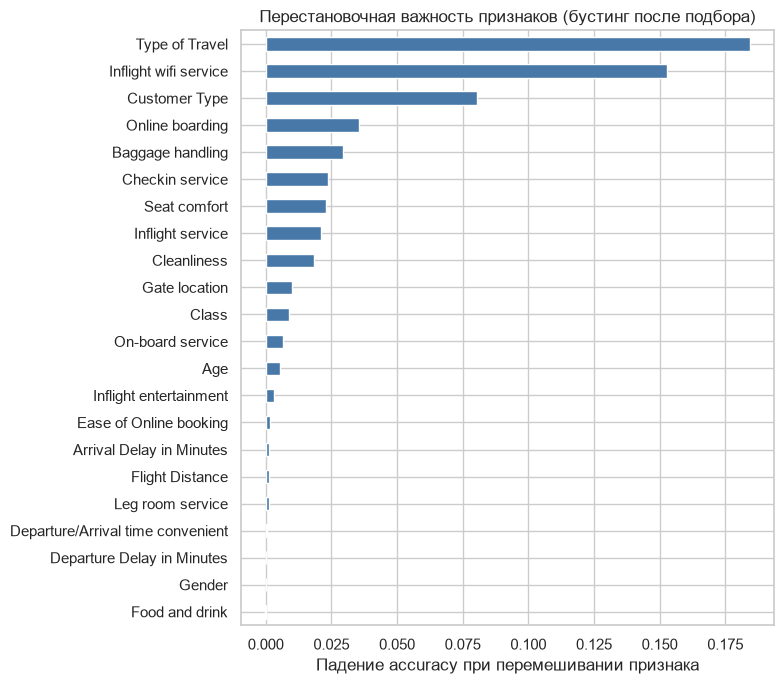

Type of Travel                       0.1843
Inflight wifi service                0.1530
Customer Type                        0.0806
Online boarding                      0.0354
Baggage handling                     0.0294
Checkin service                      0.0238
Seat comfort                         0.0228
Inflight service                     0.0211
Cleanliness                          0.0185
Gate location                        0.0098
Class                                0.0090
On-board service                     0.0065
Age                                  0.0054
Inflight entertainment               0.0031
Ease of Online booking               0.0015
Arrival Delay in Minutes             0.0013
Flight Distance                      0.0011
Leg room service                     0.0011
Departure/Arrival time convenient    0.0006
Departure Delay in Minutes           0.0001
Gender                               0.0000
Food and drink                      -0.0001
dtype: float64


In [32]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_model, X_test, y_test, scoring='accuracy',
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=4)
importances = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
importances.plot.barh(ax=ax, color='#4878a8')
ax.set_title('Перестановочная важность признаков (бустинг после подбора)')
ax.set_xlabel('Падение accuracy при перемешивании признака')
fig.tight_layout()
save_fig('16_feature_importance.png')
plt.show()

print(importances.sort_values(ascending=False).round(4))

**Рисунок 16 — Перестановочная важность признаков лучшей модели**

Сильнее всего модель опирается на цель поездки (без неё accuracy падает на 18,4 п. п.), Wi-Fi на борту (15,3 п. п.) и лояльность клиента (8,1 п. п.), а пол, питание и задержка вылета почти ничего не добавляют.

### 9.3 Кривая обучения

Проверяю, хватает ли данных и нет ли переобучения: обучаю модель на 10 %, 32 %, 55 %, 77 % и 100 %
обучающей выборки и сравниваю accuracy на обучении и на кросс-валидации.

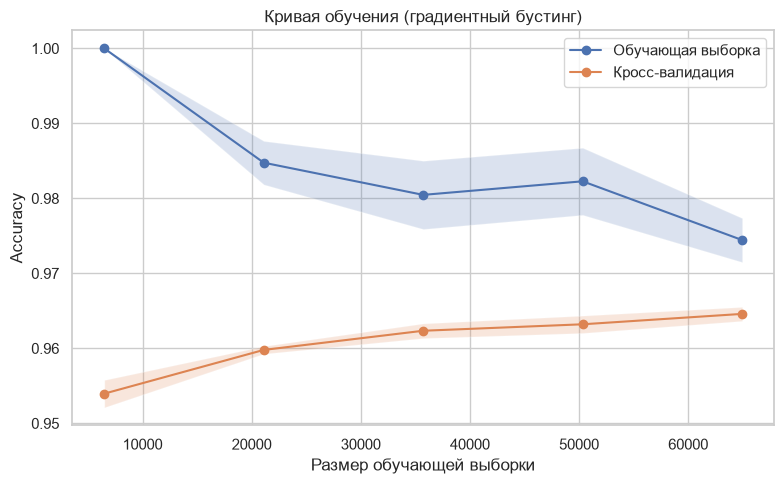

  6494 строк: обучение 1.0000, валидация 0.9540, разрыв 0.0460
 21105 строк: обучение 0.9848, валидация 0.9598, разрыв 0.0250
 35717 строк: обучение 0.9805, валидация 0.9623, разрыв 0.0181
 50328 строк: обучение 0.9823, валидация 0.9632, разрыв 0.0191
 64940 строк: обучение 0.9744, валидация 0.9646, разрыв 0.0099


In [33]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    HistGradientBoostingClassifier(**grid.best_params_, max_iter=500, random_state=RANDOM_STATE),
    X_train, y_train, cv=3, n_jobs=4,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy')

fig, ax = plt.subplots(figsize=(8, 5))
for scores, label in [(train_scores, 'Обучающая выборка'), (val_scores, 'Кросс-валидация')]:
    mean, std = scores.mean(axis=1), scores.std(axis=1)
    ax.plot(train_sizes, mean, 'o-', label=label)
    ax.fill_between(train_sizes, mean - std, mean + std, alpha=0.2)
ax.set_xlabel('Размер обучающей выборки')
ax.set_ylabel('Accuracy')
ax.set_title('Кривая обучения (градиентный бустинг)')
ax.legend()
fig.tight_layout()
save_fig('17_learning_curve.png')
plt.show()

for n, tr, va in zip(train_sizes, train_scores.mean(axis=1), val_scores.mean(axis=1)):
    print(f'{n:6} строк: обучение {tr:.4f}, валидация {va:.4f}, разрыв {tr - va:.4f}')

**Рисунок 17 — Кривая обучения градиентного бустинга**

Разрыв между обучением и валидацией сокращается с 4,6 п. п. на 6 494 строках до 1,0 п. п. на 64 940, а валидационная accuracy растёт уже медленно (0,9632 → 0,9646), так что сильного переобучения нет и новые данные добавили бы только десятые доли процента.

In [34]:
print('Отчёт по лучшей модели (градиентный бустинг после подбора):\n')
print(classification_report(y_test, best_model.predict(X_test),
                            target_names=['недоволен', 'доволен'], digits=4))

Отчёт по лучшей модели (градиентный бустинг после подбора):

              precision    recall  f1-score   support

   недоволен     0.9572    0.9822    0.9695     18363
     доволен     0.9760    0.9429    0.9591     14107

    accuracy                         0.9651     32470
   macro avg     0.9666    0.9625    0.9643     32470
weighted avg     0.9654    0.9651    0.9650     32470



### 9.4 Выводы

1. **Лучшая модель:** градиентный бустинг после подбора гиперпараметров. На тесте из 32 470 анкет
   accuracy 0,9651, precision 0,9760, recall 0,9429, F1 0,9591, ROC-AUC 0,9957. Модель ошибается
   примерно в 35 случаях из 1000 и чаще пропускает довольных (recall по довольным 0,943), чем недовольных (0,982).
2. **Порядок моделей:** бустинг 0,9651, случайный лес 0,9622, дерево 0,9464, kNN с масштабом 0,9283,
   логистическая регрессия с масштабом 0,8747. Ансамбли деревьев выигрывают, потому что зависимость
   нелинейная и признаки влияют в сочетании: дорогой класс повышает удовлетворённость только
   в деловых поездках (рисунок 9).
3. **Что дало улучшение:** стандартизация +17,6 п. п. для kNN и +0,6 п. п. для логистической регрессии,
   подбор гиперпараметров +0,18 п. п. для бустинга, отбор признаков по корреляции −0,12 п. п.
   Отрицательный результат тоже полезный: слабая линейная корреляция не значит, что признак бесполезен
   для нелинейной модели.
4. **Главные факторы:** цель поездки, Wi-Fi на борту, лояльность и онлайн-посадка. У Class корреляция
   с целью 0,49, а перестановочная важность всего 0,9 п. п.: класс сильно связан с целью поездки (r = 0,55),
   и модель берёт эту информацию оттуда. Авиакомпании в первую очередь стоит чинить Wi-Fi: у него
   самая низкая средняя оценка (2,73) и вторая по величине важность.
5. **Обучение без учителя** естественных групп не нашло: на графике инерции нет локтя, ARI кластеров
   с настоящими классами 0,28.
6. **Сравнение с существующими решениями.** В работе T. Mirthipati (arXiv:2405.09076, 2024) на этом же
   датасете случайный лес, SVM и градиентный бустинг получили accuracy 0,95 на тесте, дерево 0,92,
   логистическая регрессия 0,87. У меня логистическая регрессия дала столько же (0,869), а ансамбли
   на 1–1,5 п. п. выше. Протоколы разбиения разные, поэтому точного сравнения нет, но порядок моделей совпадает.
7. **Перспективы:** CatBoost или LightGBM с нативной обработкой категорий; SHAP, чтобы объяснять прогноз
   для конкретного пассажира; сдвиг порога, если авиакомпании важнее находить недовольных;
   проверка модели на анкетах другой авиакомпании, потому что все данные здесь из одного опроса.